# CSR Setup (comparing impact of dependency sharing)

This analysis shows how sharing dependencies can impact the overal performance of the web page. 

Sharing dependencies is done in the native-federation configuration, and dependencies are external libraries/packages. 

In [2]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import scipy.stats as stats
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: '%.2f' % x)
path = '../../../../playwright/results/core-web-vitals/testrun-9/'
plt.rcParams.update({'font.size': 14})

def detect_outliers(_df, _features, contamination=0.1):
    clf = IsolationForest(contamination=contamination, random_state=42)
    outliers = clf.fit_predict(_df[_features])
    return outliers == 1

features = ['navTime', 'totalTime', 'lcp', 'fcp', 'ttfb', 'tbt', 'tti', 'longestTask', 'longTasks', 'nf:init', 'nf:config','nf:loaded']
target_features = ['ttfb', 'lcp', 'tbt',  'tti', 'longestTask', 'nf:init', 'nf:loaded']

## clean up of non-shared-dependencies context (Outlier removal)

In [3]:
dirty_dfs = {
    'default': pd.read_csv(f'{path}results-csr.csv', sep=',')[5:],
    'throttled': pd.read_csv(f'{path}results-csr-throttled.csv', sep=',')[5:],
    'heavy': pd.read_csv(f'{path}results-csr-throttled-heavy.csv', sep=',')[5:],
}

masks = {}
dfs = {}
for name, _df in dirty_dfs.items():
    mask = detect_outliers(_df, target_features)
    masks[name] = mask
    dfs[name] = _df[mask].copy()

## clean up of shared-dependencies context (Outlier removal)

In [4]:
dirty_dfs_sd = {
    'default': pd.read_csv(f'{path}results-csr-sd.csv', sep=',')[5:],
    'throttled': pd.read_csv(f'{path}results-csr-sd-throttled.csv', sep=',')[5:],
    'heavy': pd.read_csv(f'{path}results-csr-sd-throttled-heavy.csv', sep=',')[5:],
}

masks = {}
dfs_sd = {}
for name, _df in dirty_dfs_sd.items():
    mask = detect_outliers(_df, target_features)
    masks[name] = mask
    dfs_sd[name] = _df[mask].copy()

# Quick overview of performance difference

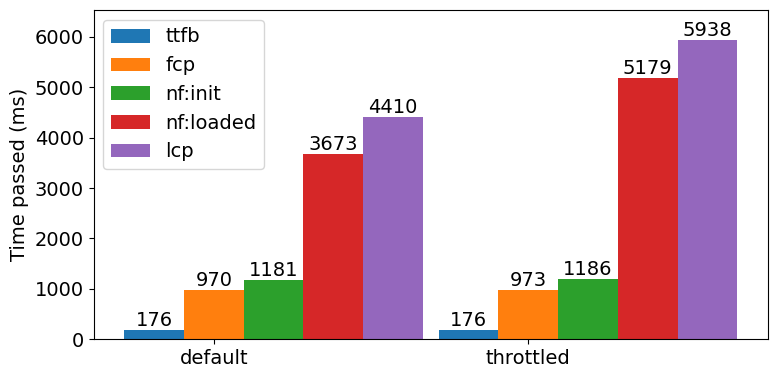

In [17]:
metrics = ['ttfb', 'fcp', 'nf:init', 'nf:loaded','lcp']
contexts = ['default', 'throttled']

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(contexts))
width = 0.19

max_height = 0
for i, m in enumerate(metrics):
    values = [dfs['throttled'][m].quantile(0.75), dfs_sd['throttled'][m].quantile(0.75)]
    max_height = max(max_height, max(values))
    bars = ax.bar(x + i*width, values, width, label=m)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom')

ax.set_ylim(0, max_height * 1.1)

ax.set_ylabel('Time passed (ms)')
ax.set_xticks(x + width)
ax.set_xticklabels(contexts)
ax.legend()

plt.tight_layout()
plt.show()


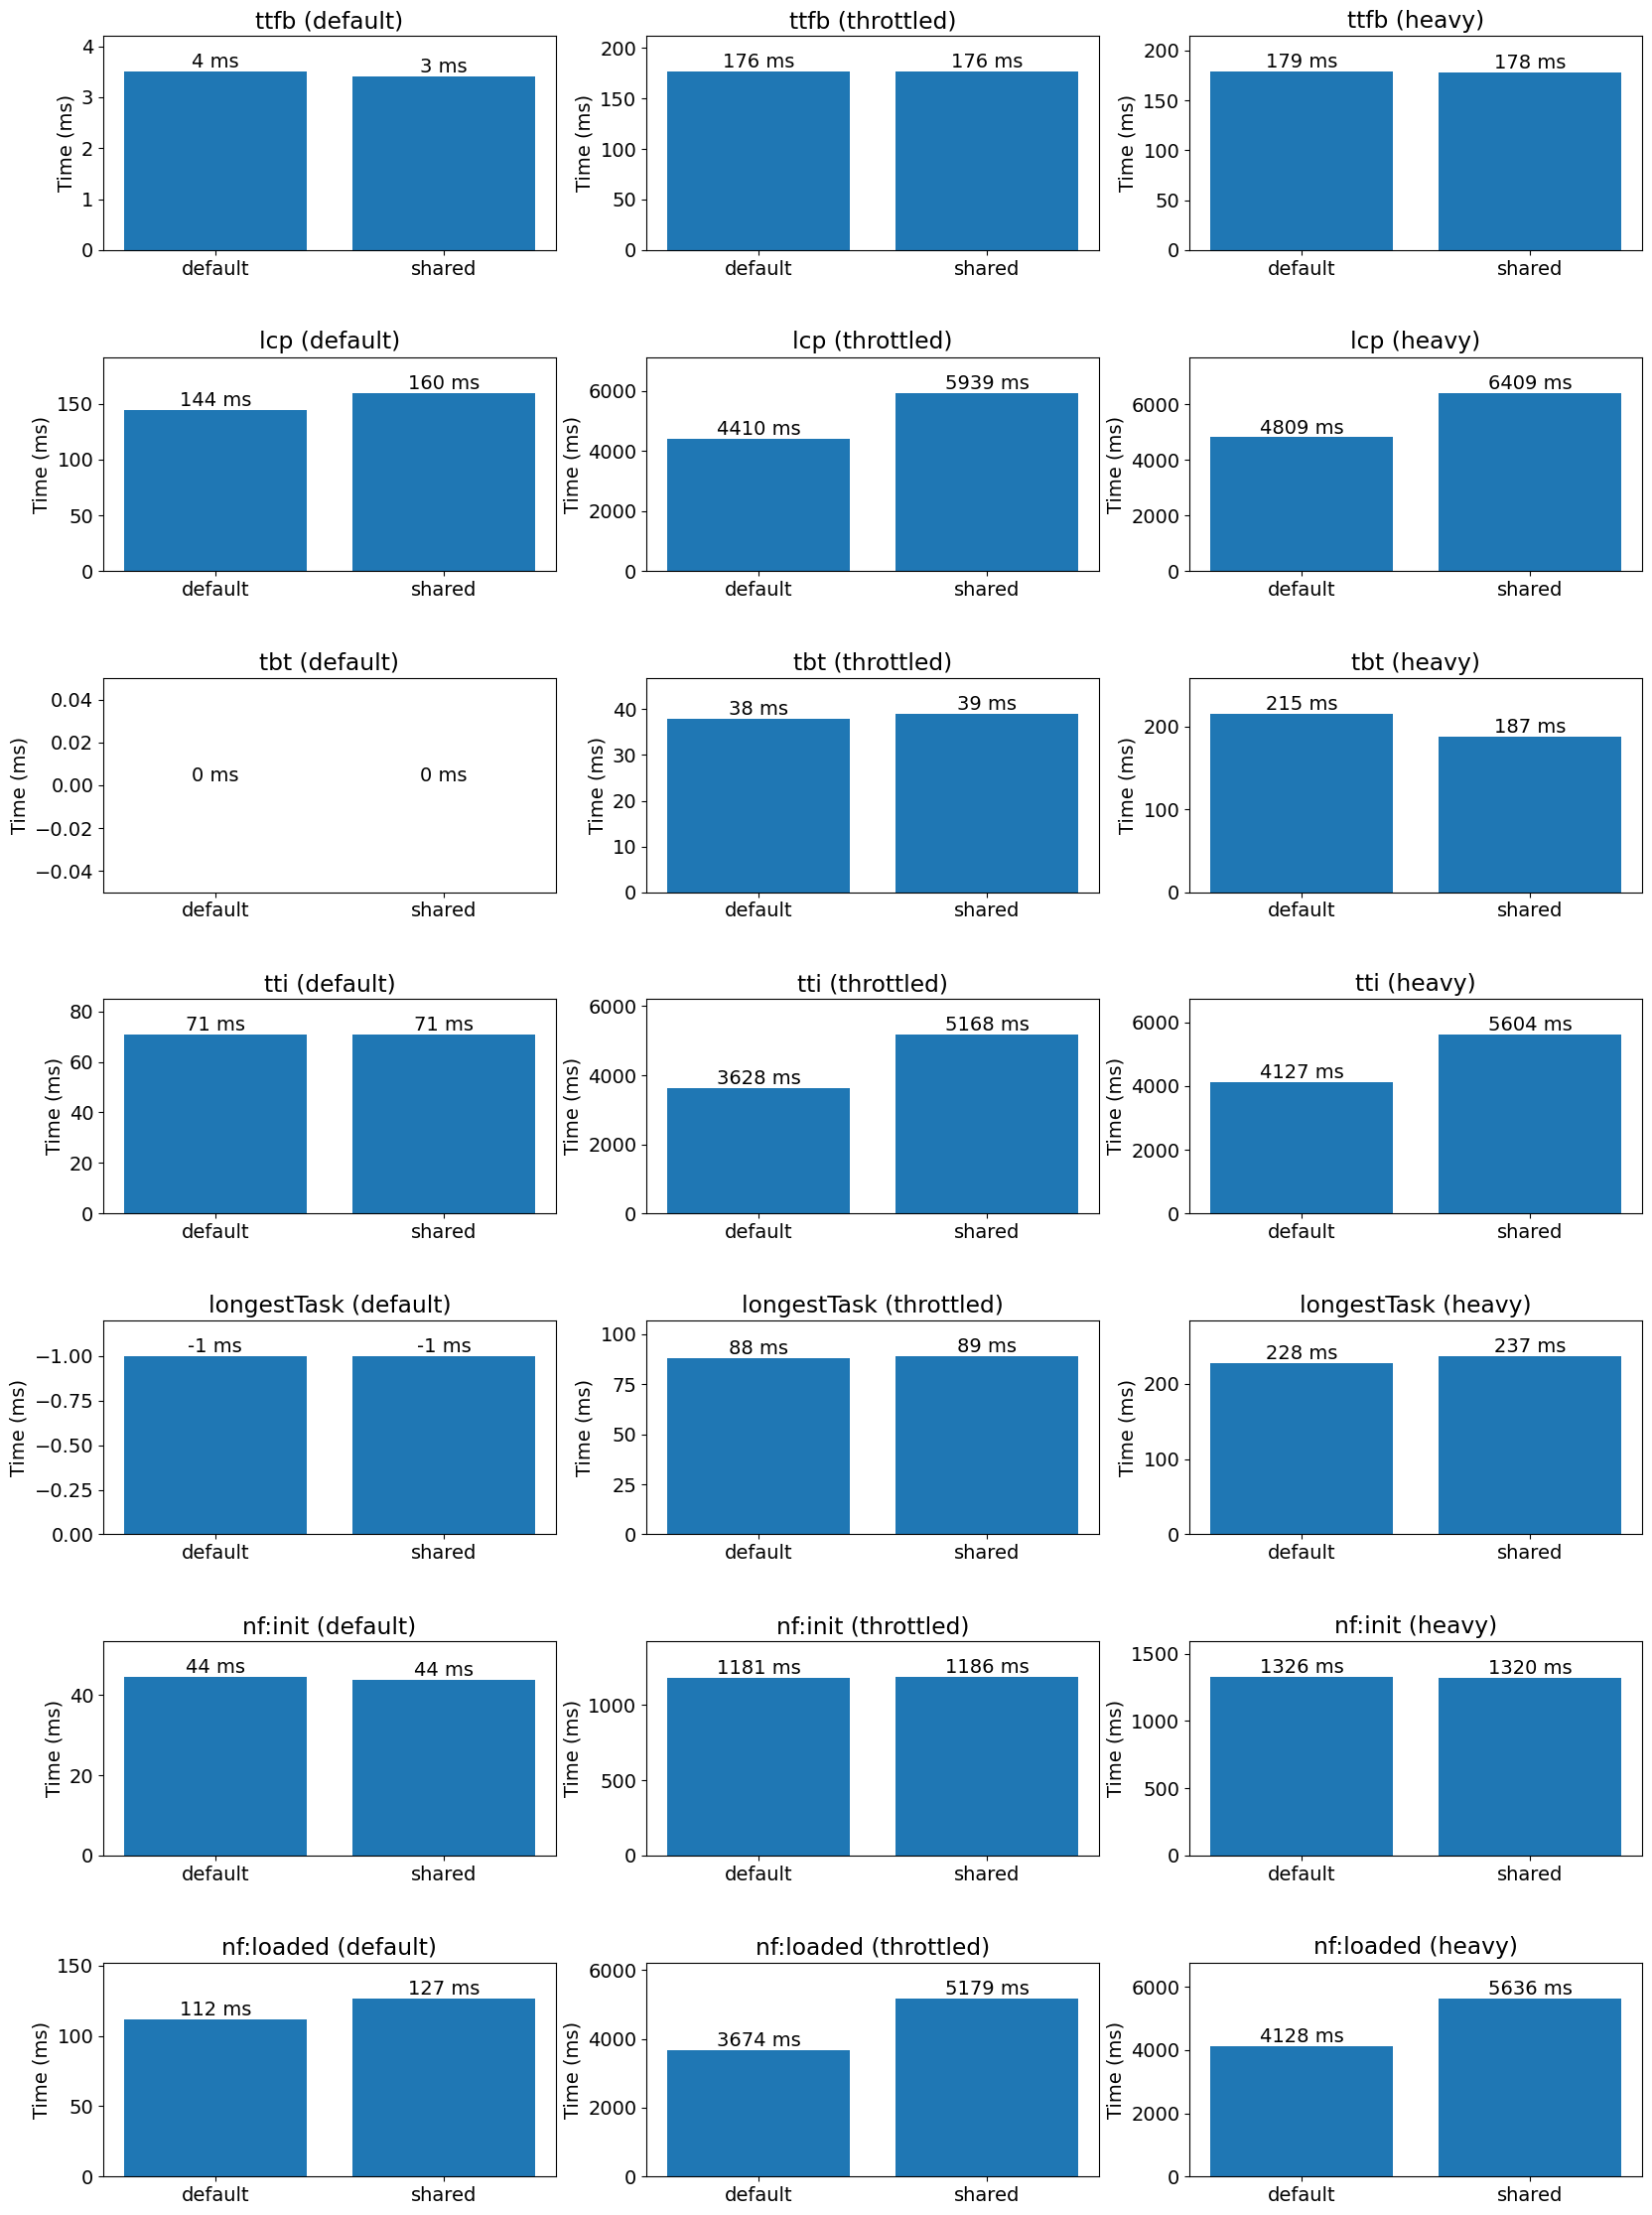

In [6]:
fig, axes = plt.subplots(nrows=len(target_features), ncols=len(dfs.keys()), figsize=(20, 4*len(target_features)))
plt.subplots_adjust(hspace=0.5)

for y, f in enumerate(target_features):
    for x, d in enumerate(dfs.keys()):
        percentiles = {
            'default': dfs[d][f].quantile(0.75),
            'shared': dfs_sd[d][f].quantile(0.75),
        }
        bars = axes[y, x].bar(percentiles.keys(), percentiles.values())
        
        max_height = max(percentiles.values())
        axes[y, x].set_ylim(0, max_height * 1.2)
        
        for i, bar in enumerate(bars):
            height = bar.get_height()
            label = f'{int(round(height, 0))} ms'
            axes[y, x].text(bar.get_x() + bar.get_width()/2., height, label, ha='center', va='bottom')
        
        axes[y, x].set_title(f'{f} ({d})')
        axes[y, x].set_ylabel('Time (ms)')

plt.show()